In [2]:
! pip install requests pandas numpy matplotlib
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re

import warnings
warnings.filterwarnings("ignore")

  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached certifi-2026.6.17-py3-none-any.whl (133 kB)

   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]



In [3]:
url = "https://remoteok.com/api"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
data = response.json()

print(type(data))

print("Total Records:", len(data))

<class 'list'>
Total Records: 101


In [5]:
print(json.dumps(data[1], indent=4))

{
    "slug": "remote-supply-chain-analyst-diva-1134516",
    "id": "1134516",
    "epoch": 1783209600,
    "date": "2026-07-05T00:00:00+00:00",
    "company": "DIVA",
    "company_logo": "",
    "position": "Supply Chain Analyst",
    "tags": [
        "analyst",
        "sys admin",
        "customer support",
        "travel",
        "accounting",
        "finance",
        "education",
        "assembly",
        "exec",
        "ops",
        "marketing",
        "excel",
        "sales",
        "medical"
    ],
    "description": "<span><span><span><strong><span>Sr. Supply Chain Specialist (12m Maternity Leave Contract)<br><br></span></strong></span></span></span><span><span><span><span><span><span>Diva International Inc. (\u00e2\u0080\u009cDIVA\u00e2\u0080\u009d) is looking for a Sr. Supply Chain Specialist (12m Maternity Leave Contract) who will be responsible</span></span></span> <span><span><span>supporting inventory management, forecasting, supply chain operations, purchas

In [6]:
jobs=[]


for job in data[1:]:

    jobs.append({

        "Job_Title": job.get("position"),

        "Company_Name": job.get("company"),

        "Location": job.get("location"),

        "Skills": ",".join(
            job.get("tags", [])
        ),

        "Salary_Min": job.get("salary_min"),

        "Salary_Max": job.get("salary_max"),

        "Job_Category": job.get("category"),

        "Posting_Date": job.get("date"),

        "Apply_Link": job.get("url")

    })

In [7]:
df = pd.DataFrame(jobs)

df.head()

,Job_Title,Company_Name,Location,Skills,Salary_Min,Salary_Max,Job_Category,Posting_Date,Apply_Link
0,Supply Chain Analyst,DIVA,"Kitchener, Kitchener, Ontario, Canada","analyst,sys admin,customer support,travel,acco...",0,0,None,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
1,Junior Front End Developer,PULSEMEDIA (MENA),"Ø§ÙØ±ÙØ§Ø¶, Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ³...","front end,dev,design,react,wordpress,full stac...",0,0,None,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-junior...
2,dishwasher,PÃ¼r &amp; Simple,"Dieppe,","analyst,exec,recruiter,education",0,0,None,2026-07-04T22:40:52+00:00,https://remoteOK.com/remote-jobs/remote-dishwa...
3,Human Resources Generalist,CoberonChronos,New York City Metropolitan Area,"design,hr,sys admin,customer support,dev,payro...",0,0,None,2026-07-04T21:10:36+00:00,https://remoteOK.com/remote-jobs/remote-human-...
4,Lead Data Scientist,Brigit,San Francisco,"python,education,customer support,testing,mark...",0,0,None,2026-07-04T16:00:08+00:00,https://remoteOK.com/remote-jobs/remote-lead-d...


In [8]:
print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

Rows: 100
Columns: 9


In [9]:
df.isnull().sum()

Job_Title         0
Company_Name      0
Location          0
Skills            0
Salary_Min        0
Salary_Max        0
Job_Category    100
Posting_Date      0
Apply_Link        0
dtype: int64

In [10]:
df.fillna(
    "Not Available",
    inplace=True
)

df.head()

,Job_Title,Company_Name,Location,Skills,Salary_Min,Salary_Max,Job_Category,Posting_Date,Apply_Link
0,Supply Chain Analyst,DIVA,"Kitchener, Kitchener, Ontario, Canada","analyst,sys admin,customer support,travel,acco...",0,0,Not Available,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
1,Junior Front End Developer,PULSEMEDIA (MENA),"Ø§ÙØ±ÙØ§Ø¶, Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ³...","front end,dev,design,react,wordpress,full stac...",0,0,Not Available,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-junior...
2,dishwasher,PÃ¼r &amp; Simple,"Dieppe,","analyst,exec,recruiter,education",0,0,Not Available,2026-07-04T22:40:52+00:00,https://remoteOK.com/remote-jobs/remote-dishwa...
3,Human Resources Generalist,CoberonChronos,New York City Metropolitan Area,"design,hr,sys admin,customer support,dev,payro...",0,0,Not Available,2026-07-04T21:10:36+00:00,https://remoteOK.com/remote-jobs/remote-human-...
4,Lead Data Scientist,Brigit,San Francisco,"python,education,customer support,testing,mark...",0,0,Not Available,2026-07-04T16:00:08+00:00,https://remoteOK.com/remote-jobs/remote-lead-d...


In [11]:
print(
    "Duplicates:",
    df.duplicated().sum()
)
df.drop_duplicates(inplace=True)

df.shape

Duplicates: 0


(100, 9)

In [12]:
df.to_csv(
    "remote_job_market_dataset.csv",
    index=False
)

print("CSV Created Successfully")

CSV Created Successfully


In [15]:
top_companies = (
    df["Company_Name"]
    .value_counts()
    .head(10)
)

top_companies

Company_Name
Recruitlytics Hiring     4
The Home Depot Canada    2
Kanahoma                 2
CXC Upstream Ltd         2
New Engen                2
DIVA                     1
PULSEMEDIA (MENA)        1
PÃ¼r &amp; Simple        1
CoberonChronos           1
Brigit                   1
Name: count, dtype: int64

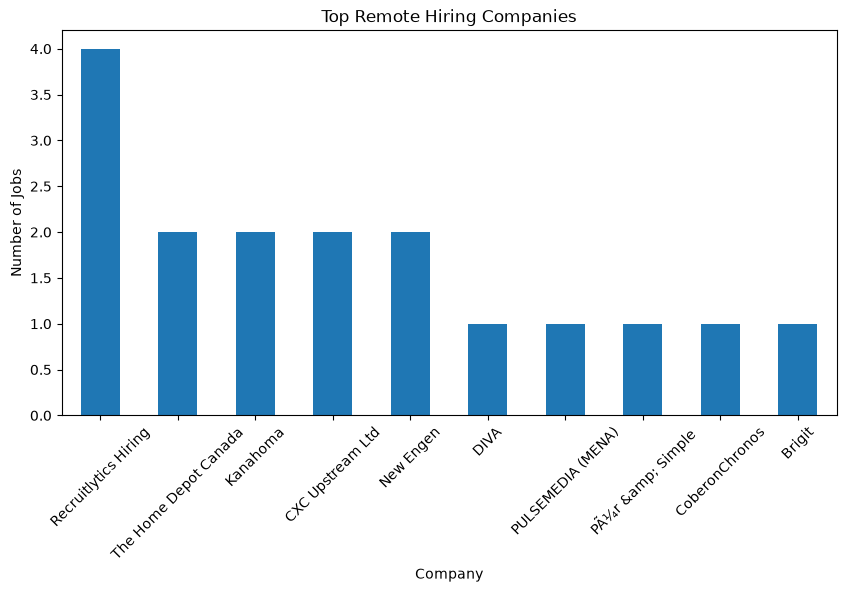

In [16]:
plt.figure(figsize=(10,5))

top_companies.plot(
    kind="bar"
)

plt.title(
    "Top Remote Hiring Companies"
)

plt.xlabel(
    "Company"
)

plt.ylabel(
    "Number of Jobs"
)

plt.xticks(rotation=45)

plt.show()

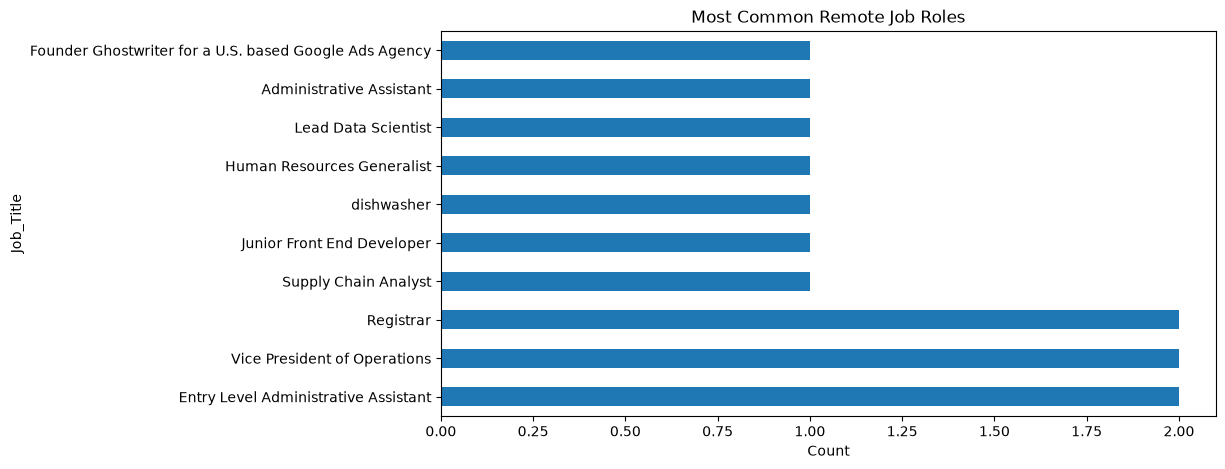

In [17]:
top_roles = (
    df["Job_Title"]
    .value_counts()
    .head(10)
)

top_roles

plt.figure(figsize=(10,5))

top_roles.plot(kind="barh")

plt.title(
    "Most Common Remote Job Roles"
)

plt.xlabel(
    "Count"
)

plt.show()

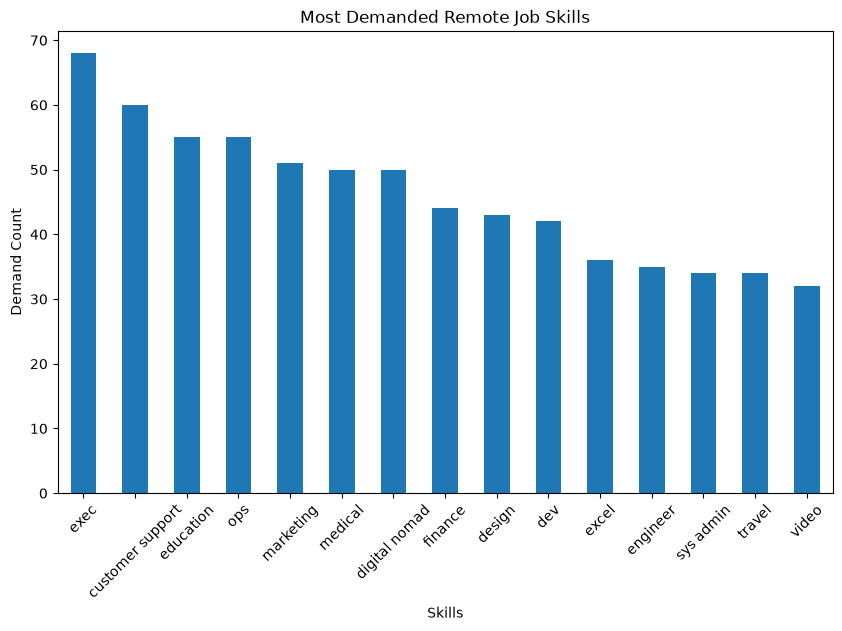

In [18]:
skills=[]


for i in df["Skills"]:

    skills.extend(
        i.split(",")
    )


skill_count = (
    pd.Series(skills)
    .value_counts()
    .head(15)
)

skill_count

plt.figure(figsize=(10,6))

skill_count.plot(
    kind="bar"
)

plt.title(
    "Most Demanded Remote Job Skills"
)

plt.xlabel(
    "Skills"
)

plt.ylabel(
    "Demand Count"
)

plt.xticks(rotation=45)

plt.show()

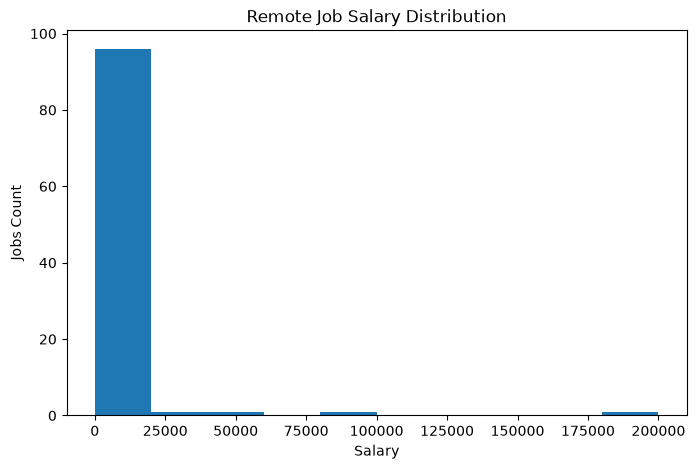

In [19]:
salary_df = df[
    df["Salary_Min"] != "Not Available"
]

salary_df.head()

plt.figure(figsize=(8,5))

plt.hist(
    salary_df["Salary_Min"]
)

plt.title(
    "Remote Job Salary Distribution"
)

plt.xlabel(
    "Salary"
)

plt.ylabel(
    "Jobs Count"
)

plt.show()

In [20]:
print("""
REMOTE JOB MARKET ANALYSIS SUMMARY

Total Jobs Analyzed:
""",len(df))


print("""
Insights:

1. Extracted live job data using JSON API

2. Stored structured job dataset

3. Analyzed top hiring companies

4. Found most demanded technologies

5. Studied remote salary trends

6. Generated visual job market reports
""")


REMOTE JOB MARKET ANALYSIS SUMMARY

Total Jobs Analyzed:
 100

Insights:

1. Extracted live job data using JSON API

2. Stored structured job dataset

3. Analyzed top hiring companies

4. Found most demanded technologies

5. Studied remote salary trends

6. Generated visual job market reports

